# 01 — Figure 1: semantic geometry motivation

Notebook tự train rồi dựng **Figure 1** từ embedding thật của cùng một semantic slice Banking77 qua ba encoder: **Teacher**, **TALAS**, và **GATE-KD**. Format đi theo notebook `00`: cấu hình → chuẩn bị repo → warm teacher cache → train TALAS/GATE-KD song song → encode/cache → cosine-MDS → render/export.

Figure không chứa performance chart hay ablation. Mỗi point cloud là classical MDS của cosine distance thật; hai student chỉ được Procrustes-align (xoay, tịnh tiến, scale đồng nhất) với teacher để cùng hệ quy chiếu. Phép align không thay đổi hình dạng hay quan hệ cặp trong từng method. Ellipse covariance chỉ tóm tắt phân bố 2-D; residual heatmap audit trực tiếp sai lệch pairwise geometry ở không gian gốc.

Notebook **không tạo dữ liệu synthetic**. Nếu một training job thất bại hoặc không sinh checkpoint epoch cuối, pipeline sẽ dừng trước các cell encode/render.


In [ ]:
# 1. Cấu hình — mặc định dùng cặp compact student và seed 42.
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

REPO_URL = "https://github.com/duncan-nguyen/embedding-kd.git"
PAIR_NAME = "qwen3_0.6b_to_minilm_h384"
PAIR = {
    "teacher": "Qwen/Qwen3-Embedding-0.6B",
    "student": "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base",
    "teacher_pooling": "last_token",
    "student_pooling": "cls",
    "min_vram_gib": 12,
}
SEED = 42
EPOCHS = 5
TRAIN_DATA_REL = Path("data/train_set/merged_3_data_5k_each.csv")
DATA_REL = Path("data/test_set/banking77_test.csv")
OUTPUT_REL = Path("docs/latex_iclr/figures")
FIGURE_STEM = "figure_1_motivation"
RUN_STAMP = datetime.now(ZoneInfo("Asia/Ho_Chi_Minh")).strftime("%Y%m%d-%H%M%S")
RUN_NAME_OVERRIDE = None  # Điền run cũ để resume sau khi restart runtime.
RUN_NAME = RUN_NAME_OVERRIDE or f"figure1_{PAIR_NAME}_seed{SEED}_{RUN_STAMP}"

METHOD_SETTINGS = {
    "talas": {"batch_size": 128, "learning_rate": 2e-5},
    "geoode": {"batch_size": 128, "learning_rate": 7e-5},
}
GEOODE_H0_BATCH_SIZE = 128
CUDA_VISIBLE_DEVICES = "0,1"
GPUS = ["0", "0"]  # Một job trên mỗi GPU; dùng ["0", "0"] để co-locate.
MAX_PARALLEL_JOBS = 1    # Số job đồng thời trên mỗi entry của GPUS.
NUM_WORKERS = 2
STOP_ON_ERROR = True
PROGRESS_EVERY_SEC = 30

SAMPLES_PER_CLASS = 40
HEATMAP_PER_CLASS = 8
ELLIPSE_SIGMA = 1.35
RANDOM_STATE = 42
ENCODE_BATCH_SIZE = 192
MAX_LENGTH = 256
RECOMPUTE_EMBEDDINGS = False
PULL_REPO = False
INSTALL_DEPS = True
SAVE_PNG = True

SELECTED_CLASSES = [
    "card_arrival",
    "cash_withdrawal_not_recognised",
    "declined_transfer",
    "exchange_rate",
    "top_up_by_cash_or_cheque",
    "verify_my_identity",
]
CLASS_NAMES = {0: "card arrival", 1: "cash withdrawal", 2: "declined transfer", 3: "exchange rate", 4: "cash top-up", 5: "identity check"}
PALETTE = {0: "#4C78A8", 1: "#F2A93B", 2: "#E66C9C", 3: "#D64B40", 4: "#6F58A8", 5: "#35A77C"}


In [ ]:
# 2. Dùng repo hiện tại hoặc clone trên Colab; cài dependency khi cần.
import importlib.util
import subprocess
import sys

cwd = Path.cwd().resolve()
PROJECT_DIR = next((p for p in (cwd, *cwd.parents) if (p / "main.py").is_file() and (p / "notebooks").is_dir()), None)
if PROJECT_DIR is None:
    clone_parent = Path("/content") if Path("/content").is_dir() else cwd
    PROJECT_DIR = clone_parent / "embedding-kd"
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)
    assert (PROJECT_DIR / "main.py").is_file(), f"Repo không hợp lệ: {PROJECT_DIR}"
if PULL_REPO:
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=True)

packages = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "sklearn": "scikit-learn", "torch": "torch", "transformers": "transformers", "pytorch_optimizer": "pytorch-optimizer>=2.12.0"}
missing = [pip_name for module, pip_name in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    if not INSTALL_DEPS:
        raise RuntimeError(f"Thiếu {missing}; đặt INSTALL_DEPS=True rồi chạy lại cell.")
    subprocess.run([sys.executable, "-m", "pip", "install", *missing], check=True)
if importlib.util.find_spec("pytorch_optimizer") is None:
    raise RuntimeError("TALAS cần pytorch-optimizer; hãy restart runtime và chạy lại từ cell 1.")

sys.path.insert(0, str(PROJECT_DIR))
import torch
if not torch.cuda.is_available():
    raise RuntimeError("Hãy bật GPU runtime trước khi chạy training.")
if hasattr(torch.cuda, "is_bf16_supported") and not torch.cuda.is_bf16_supported():
    raise RuntimeError("GPU phải hỗ trợ BF16.")
if GPUS is not None:
    invalid = [gpu for gpu in GPUS if not str(gpu).isdigit() or int(gpu) >= torch.cuda.device_count()]
    if invalid:
        raise RuntimeError(f"GPU slots không tồn tại: {invalid}; runtime có {torch.cuda.device_count()} GPU.")

OUTPUT_BASE = PROJECT_DIR / "runs"
RUN_ROOT = OUTPUT_BASE / RUN_NAME
CACHE_DIR = OUTPUT_BASE / "teacher_cache"
TRAIN_DATA = PROJECT_DIR / TRAIN_DATA_REL
DATA_PATH = PROJECT_DIR / DATA_REL
OUTPUT_DIR = PROJECT_DIR / OUTPUT_REL
CACHE_PATH = RUN_ROOT / "figure_1_banking77_embeddings.npz"
TALAS_RUN_DIR = RUN_ROOT / "talas" / f"seed_{SEED}"
GATE_RUN_DIR = RUN_ROOT / "geoode" / f"seed_{SEED}"
assert TRAIN_DATA.is_file(), f"Thiếu training corpus: {TRAIN_DATA}"
assert DATA_PATH.is_file(), f"Thiếu visualization data: {DATA_PATH}"
RUN_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
for index in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(index)
    print(f"cuda:{index}: {props.name} ({props.total_memory / 2**30:.1f} GiB)")
print(f"Project: {PROJECT_DIR}")
print(f"Run:     {RUN_ROOT}")
print(f"TALAS:   {TALAS_RUN_DIR}")
print(f"GATE-KD: {GATE_RUN_DIR}")
print(f"Cache:   {CACHE_PATH}")


In [ ]:
# 3. Tạo hai training job độc lập: TALAS và GATE-KD.
import shlex

def build_command(method, settings, output_dir):
    command = [
        sys.executable, str(PROJECT_DIR / "main.py"),
        "--method", method,
        "--train_data", str(TRAIN_DATA),
        "--student_model", PAIR["student"],
        "--teacher_model", PAIR["teacher"],
        "--teacher_pooling", PAIR["teacher_pooling"],
        "--batch_size", str(settings["batch_size"]),
        "--epochs", str(EPOCHS),
        "--save_every", str(EPOCHS),
        "--lr", str(settings["learning_rate"]),
        "--max_length", str(MAX_LENGTH),
        "--save_dir", str(output_dir),
        "--num_workers", str(NUM_WORKERS),
        "--seed", str(SEED),
        "--eval_every", "0",
        "--cache_dir", str(CACHE_DIR),
        "--no_eval_retrieval",
        "--no_wandb",
    ]
    if method == "geoode":
        command.extend([
            "--lambda_topo", "0.5",
            "--lambda_ctr", "0.0",
            "--gauge_refit_every", "1",
            "--topo_batch_size", str(GEOODE_H0_BATCH_SIZE),
        ])
    return command

JOBS = []
for method, settings in METHOD_SETTINGS.items():
    output_dir = RUN_ROOT / method / f"seed_{SEED}"
    JOBS.append({
        "name": f"{method}/seed_{SEED}",
        "method": method,
        "seed": SEED,
        "output_dir": output_dir,
        "log_path": RUN_ROOT / method / f"seed_{SEED}_train.log",
        "command": build_command(method, settings, output_dir),
    })
print(f"Plan: {len(JOBS)} jobs, seed={SEED}, corpus=15K")
for job in JOBS:
    print(f"[{job['method'].upper()}] {shlex.join(job['command'])}")


In [ ]:
# 4. Warm teacher cache, chạy TALAS/GATE-KD song song, rồi chặn figure cho tới khi đủ checkpoint.
import os
import subprocess

from src.job_runner import gpu_slots, run_jobs_parallel

def expected_checkpoint(output_dir):
    path = output_dir / f"checkpoint_epoch_{EPOCHS}.pt"
    return path if path.is_file() else None

def show_log_tail(log_path, lines=60):
    print(f"\n--- tail {log_path} ---")
    if not log_path.is_file():
        print("[log chưa được tạo]")
        return
    content = log_path.read_text(encoding="utf-8", errors="replace").replace("\r", "\n").splitlines()
    print("\n".join(content[-lines:]))

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES
env["TOKENIZERS_PARALLELISM"] = "false"
env["WANDB_MODE"] = "disabled"
env["TQDM_MININTERVAL"] = str(PROGRESS_EVERY_SEC)
slots = gpu_slots(GPUS if GPUS is not None else [CUDA_VISIBLE_DEVICES], MAX_PARALLEL_JOBS)
queued = []
for job in JOBS:
    if expected_checkpoint(job["output_dir"]):
        print(f"[SKIP] {job['name']} đã có checkpoint epoch {EPOCHS}")
        continue
    metrics_path = job["output_dir"] / "metrics.jsonl"
    if metrics_path.exists():
        show_log_tail(job["log_path"])
        raise RuntimeError(f"Run dở dang: {metrics_path}. Dùng RUN_NAME_OVERRIDE khác hoặc xử lý riêng run này.")
    job["output_dir"].mkdir(parents=True, exist_ok=True)
    job["log_path"].parent.mkdir(parents=True, exist_ok=True)
    queued.append(job)

if queued:
    warm = list(queued[0]["command"])
    start = warm.index("--save_dir")
    del warm[start:start + 2]
    print("[CACHE] warm teacher cache trước khi fan-out")
    subprocess.run([*warm, "--cache_only"], cwd=PROJECT_DIR, env=env, check=True)

    def on_finish(job, row):
        complete = row["returncode"] == 0 and expected_checkpoint(job["output_dir"]) is not None
        return {**row, "status": "complete" if complete else "failed"}

    print(f"[PARALLEL] {len(queued)} jobs trên {len(slots)} slots: {slots}")
    rows = run_jobs_parallel(
        queued, cwd=PROJECT_DIR, env=env, slots=slots,
        stop_on_error=STOP_ON_ERROR, on_finish=on_finish,
        poll_seconds=PROGRESS_EVERY_SEC,
    )
    failed = [row for row in rows if row["status"] != "complete"]
    if failed:
        for row in failed:
            show_log_tail(Path(row["log_path"]))
        raise RuntimeError("Training chưa hoàn tất: " + ", ".join(row["name"] for row in failed))

TALAS_CHECKPOINT = expected_checkpoint(TALAS_RUN_DIR)
GATE_CHECKPOINT = expected_checkpoint(GATE_RUN_DIR)
assert TALAS_CHECKPOINT and GATE_CHECKPOINT, "Figure bị chặn vì chưa đủ TALAS/GATE-KD checkpoints."
print(f"Ready: {TALAS_CHECKPOINT}")
print(f"Ready: {GATE_CHECKPOINT}")


In [ ]:
# 5. Chọn semantic slice Banking77 cân bằng và kiểm tra checkpoint thật.
import numpy as np
import pandas as pd

frame = pd.read_csv(DATA_PATH)
assert {"text", "label_text"}.issubset(frame.columns), f"Schema không hợp lệ: {DATA_PATH}"
missing_classes = sorted(set(SELECTED_CLASSES) - set(frame["label_text"]))
assert not missing_classes, f"Banking77 classes không tồn tại: {missing_classes}"
class_to_id = {name: index for index, name in enumerate(SELECTED_CLASSES)}
frame = frame[frame["label_text"].isin(SELECTED_CLASSES)].copy()
frame["viz_label"] = frame["label_text"].map(class_to_id).astype(int)
class_counts = frame.groupby("viz_label").size().reindex(sorted(CLASS_NAMES))
samples_per_class = min(SAMPLES_PER_CLASS, int(class_counts.min()))
assert samples_per_class >= HEATMAP_PER_CLASS, (
    f"Lớp nhỏ nhất chỉ có {samples_per_class} mẫu, không đủ cho heatmap."
)
if samples_per_class < SAMPLES_PER_CLASS:
    print(f"[BALANCE] dùng {samples_per_class} mẫu/lớp; requested={SAMPLES_PER_CLASS}, min class={int(class_counts.min())}")
rng = np.random.default_rng(RANDOM_STATE)
selected = []
for label in sorted(CLASS_NAMES):
    group = frame[frame["viz_label"] == label]
    chosen = rng.choice(group.index.to_numpy(), size=samples_per_class, replace=False)
    selected.append(frame.loc[chosen])
sample = pd.concat(selected, ignore_index=True)
texts = sample["text"].astype(str).tolist()
labels = sample["viz_label"].to_numpy(dtype=np.int64)

def final_checkpoint(run_dir):
    candidates = [run_dir / f"checkpoint_epoch_{EPOCHS}.pt", run_dir / "best_model.pt"]
    candidates.extend(sorted(run_dir.glob("checkpoint_epoch_*.pt"), reverse=True))
    return next((path for path in candidates if path.is_file()), None)

TALAS_CHECKPOINT = final_checkpoint(TALAS_RUN_DIR)
GATE_CHECKPOINT = final_checkpoint(GATE_RUN_DIR)
if RECOMPUTE_EMBEDDINGS or not CACHE_PATH.is_file():
    missing_artifacts = [name for name, path in {"TALAS": TALAS_CHECKPOINT, "GATE-KD": GATE_CHECKPOINT}.items() if path is None]
    if missing_artifacts:
        raise FileNotFoundError(
            "Không có cache embedding và thiếu checkpoint: " + ", ".join(missing_artifacts) +
            ". Sửa RUN_ROOT/TALAS_RUN_DIR/GATE_RUN_DIR tới máy chứa run 15K."
        )
print(sample.groupby("viz_label").size().rename(index=CLASS_NAMES))
print(f"TALAS checkpoint: {TALAS_CHECKPOINT}")
print(f"GATE checkpoint:  {GATE_CHECKPOINT}")


In [10]:
# 6. Encode teacher/TALAS/GATE-KD một lần; những lần sau đọc NPZ cache.
import gc

if CACHE_PATH.is_file() and not RECOMPUTE_EMBEDDINGS:
    cached = np.load(CACHE_PATH)
    teacher_emb = cached["teacher"]
    talas_emb = cached["talas"]
    gate_emb = cached["gate"]
    assert np.array_equal(cached["labels"], labels), "Cache dùng sample selection khác; bật RECOMPUTE_EMBEDDINGS."
    assert np.array_equal(cached["texts"].astype(str), np.asarray(texts)), "Dataset đã thay đổi; bật RECOMPUTE_EMBEDDINGS."
    print(f"Loaded real embeddings: {CACHE_PATH}")
else:
    import torch
    from transformers import AutoModel, AutoTokenizer
    from src.structural_audit import encode_texts, load_student

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    def clear_memory():
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    teacher_tokenizer = AutoTokenizer.from_pretrained(PAIR["teacher"], trust_remote_code=True)
    teacher_model = AutoModel.from_pretrained(PAIR["teacher"], torch_dtype="auto", trust_remote_code=True).to(device).eval()
    teacher_emb = encode_texts(teacher_model, teacher_tokenizer, texts, device=device, pooling=PAIR["teacher_pooling"], batch_size=ENCODE_BATCH_SIZE, max_length=MAX_LENGTH, progress=True)["final"].numpy()
    del teacher_model
    clear_memory()

    student_tokenizer = AutoTokenizer.from_pretrained(PAIR["student"])
    talas_model = load_student(PAIR["student"], TALAS_CHECKPOINT, device=device)
    talas_emb = encode_texts(talas_model, student_tokenizer, texts, device=device, pooling=PAIR["student_pooling"], batch_size=ENCODE_BATCH_SIZE, max_length=MAX_LENGTH, progress=True)["final"].numpy()
    del talas_model
    clear_memory()

    gate_model = load_student(PAIR["student"], GATE_CHECKPOINT, device=device)
    gate_emb = encode_texts(gate_model, student_tokenizer, texts, device=device, pooling=PAIR["student_pooling"], batch_size=ENCODE_BATCH_SIZE, max_length=MAX_LENGTH, progress=True)["final"].numpy()
    del gate_model
    clear_memory()
    np.savez_compressed(CACHE_PATH, teacher=teacher_emb, talas=talas_emb, gate=gate_emb, labels=labels, texts=np.asarray(texts, dtype=str))
    print(f"Saved real embeddings: {CACHE_PATH}")

assert teacher_emb.shape[0] == talas_emb.shape[0] == gate_emb.shape[0] == len(labels)
print({"teacher": teacher_emb.shape, "TALAS": talas_emb.shape, "GATE-KD": gate_emb.shape})


Loaded real embeddings: /content/embedding-kd/runs/figure1_qwen3_0.6b_to_minilm_h384_seed42_20260905-005246/figure_1_banking77_embeddings.npz
{'teacher': (240, 1024), 'TALAS': (240, 384), 'GATE-KD': (240, 384)}


In [11]:
# 7. Cosine-MDS faithful to each geometry; align only the plotting frame.
def unit(x):
    x = np.asarray(x, dtype=np.float32)
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), 1e-12)

teacher_emb, talas_emb, gate_emb = map(unit, (teacher_emb, talas_emb, gate_emb))

def cosine_mds(embedding):
    # Classical MDS from the complete cosine-distance matrix: deterministic, label-free.
    similarity = np.clip(embedding @ embedding.T, -1.0, 1.0)
    distance_sq = np.maximum(0.0, 2.0 - 2.0 * similarity)
    centered = distance_sq - distance_sq.mean(0, keepdims=True)
    centered = centered - centered.mean(1, keepdims=True) + distance_sq.mean()
    gram = -0.5 * centered
    eigenvalues, eigenvectors = np.linalg.eigh(gram)
    order = np.argsort(eigenvalues)[::-1][:2]
    return eigenvectors[:, order] * np.sqrt(np.maximum(eigenvalues[order], 0.0))[None, :]

def procrustes_align(points, reference):
    # Similarity transform changes only the plotting frame, never the cloud shape.
    source = points - points.mean(axis=0, keepdims=True)
    target = reference - reference.mean(axis=0, keepdims=True)
    left, singular, right = np.linalg.svd(source.T @ target, full_matrices=False)
    rotation = left @ right
    scale = singular.sum() / max(float(np.square(source).sum()), 1e-12)
    return scale * source @ rotation + reference.mean(axis=0, keepdims=True)

teacher_xy = cosine_mds(teacher_emb)
talas_xy = procrustes_align(cosine_mds(talas_emb), teacher_xy)
gate_xy = procrustes_align(cosine_mds(gate_emb), teacher_xy)

heatmap_idx = []
for label in sorted(CLASS_NAMES):
    idx = np.flatnonzero(labels == label)
    center = unit(teacher_emb[idx].mean(axis=0, keepdims=True))[0]
    ordered = idx[np.argsort(-(teacher_emb[idx] @ center))]
    heatmap_idx.extend(ordered[:HEATMAP_PER_CLASS])
heatmap_idx = np.asarray(heatmap_idx)
def cosine_matrix(x): return x[heatmap_idx] @ x[heatmap_idx].T
teacher_cos = cosine_matrix(teacher_emb)
talas_residual = np.abs(cosine_matrix(talas_emb) - teacher_cos)
gate_residual = np.abs(cosine_matrix(gate_emb) - teacher_cos)
np.fill_diagonal(talas_residual, 0.0); np.fill_diagonal(gate_residual, 0.0)

geometry = {"Teacher": (teacher_emb, teacher_xy), "TALAS": (talas_emb, talas_xy), "GATE-KD": (gate_emb, gate_xy)}


NameError: name 'ELLIPSE_SIGMA' is not defined

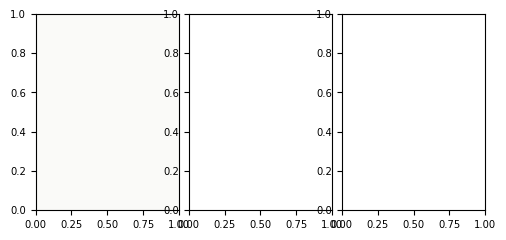

In [12]:
# 8. Render: semantic constellations + dimension-invariant geometry residual.
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/embedding-kd-matplotlib")
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

matplotlib.rcParams.update({"font.family": "DejaVu Sans", "font.size": 7.2, "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 300})
all_xy = np.vstack([teacher_xy, talas_xy, gate_xy])
lo = np.quantile(all_xy, 0.01, axis=0); hi = np.quantile(all_xy, 0.99, axis=0)
pad = 0.08 * np.maximum(hi - lo, 1e-6)
xlim = (lo[0] - pad[0], hi[0] + pad[0]); ylim = (lo[1] - pad[1], hi[1] + pad[1])

def add_covariance_ellipse(ax, points, color):
    center = points.mean(axis=0)
    covariance = np.cov(points, rowvar=False)
    values, vectors = np.linalg.eigh(covariance)
    order = np.argsort(values)[::-1]
    values, vectors = np.maximum(values[order], 1e-12), vectors[:, order]
    angle = np.degrees(np.arctan2(vectors[1, 0], vectors[0, 0]))
    width, height = 2.0 * ELLIPSE_SIGMA * np.sqrt(values)
    ellipse = Ellipse(
        center, width, height, angle=angle,
        facecolor=matplotlib.colors.to_rgba(color, 0.075),
        edgecolor=matplotlib.colors.to_rgba(color, 0.48),
        linewidth=0.65, zorder=1,
    )
    ax.add_patch(ellipse)
    return center

def cloud_panel(ax, panel, name, dimension, xy, accent):
    ax.set_facecolor("#FAFAF8")
    for label in sorted(CLASS_NAMES):
        mask = labels == label
        points = xy[mask]
        centroid = add_covariance_ellipse(ax, points, PALETTE[label])
        ax.scatter(points[:, 0], points[:, 1], s=8.5, c=PALETTE[label], alpha=0.72, linewidths=0, rasterized=True, zorder=2)
        ax.scatter(*centroid, s=24, c=PALETTE[label], edgecolors="white", linewidths=0.8, zorder=3)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_title(f"({panel})  {name}", loc="left", color=accent, fontsize=8.6, fontweight="bold", pad=4)
    ax.text(0.99, 1.015, dimension, transform=ax.transAxes, color="#777C85", fontsize=5.5, ha="right", va="bottom")

fig = plt.figure(figsize=(7.45, 2.55), facecolor="white")
grid = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 0.73, 0.025], height_ratios=[1, 1], wspace=0.09, hspace=0.25)
cloud_axes = [fig.add_subplot(grid[:, col]) for col in range(3)]
cloud_panel(cloud_axes[0], "a", "Teacher", "1024-D", teacher_xy, "#B45F06")
cloud_panel(cloud_axes[1], "b", "TALAS", "384-D", talas_xy, "#596579")
cloud_panel(cloud_axes[2], "c", "GATE-KD", "384-D", gate_xy, "#5B43B4")

vmax = np.quantile(np.concatenate([talas_residual.ravel(), gate_residual.ravel()]), 0.98)
heat_axes = [fig.add_subplot(grid[row, 3]) for row in range(2)]
for ax, residual, title in zip(heat_axes, [talas_residual, gate_residual], ["TALAS", "GATE-KD"]):
    image = ax.imshow(residual, cmap="magma_r", vmin=0, vmax=vmax, interpolation="nearest", aspect="equal")
    for boundary in range(HEATMAP_PER_CLASS, len(heatmap_idx), HEATMAP_PER_CLASS):
        ax.axhline(boundary - 0.5, color="white", linewidth=0.35, alpha=0.75)
        ax.axvline(boundary - 0.5, color="white", linewidth=0.35, alpha=0.75)
    ax.set_title(title, fontsize=6.4, fontweight="bold", pad=2)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
heat_axes[0].text(0.5, 1.22, "(d)  Geometry residual", transform=heat_axes[0].transAxes, ha="center", fontsize=7.0, fontweight="bold")
cax = fig.add_subplot(grid[:, 4])
cbar = fig.colorbar(image, cax=cax)
cbar.set_label(r"$|\Delta\,\mathrm{cos}|$", fontsize=5.6, labelpad=2)
cbar.ax.tick_params(labelsize=5.0, length=1.8, width=0.45)
cbar.outline.set_linewidth(0.45)

handles = [Line2D([0], [0], marker="o", color="none", markerfacecolor=PALETTE[label], markeredgecolor="none", markersize=4.2, label=CLASS_NAMES[label]) for label in sorted(CLASS_NAMES)]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.43, 0.005), ncol=6, frameon=False, fontsize=5.8, handletextpad=0.25, columnspacing=0.85)
fig.subplots_adjust(left=0.012, right=0.985, top=0.92, bottom=0.14)
pdf_path = OUTPUT_DIR / f"{FIGURE_STEM}.pdf"
png_path = OUTPUT_DIR / f"{FIGURE_STEM}.png"
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.035)
if SAVE_PNG: fig.savefig(png_path, bbox_inches="tight", pad_inches=0.035)
plt.show()
print(f"Saved: {pdf_path}")
if SAVE_PNG: print(f"Saved: {png_path}")


In [ ]:
# 9. Export provenance và coordinates để figure có thể audit độc lập.
positions = []
for method, (_, xy) in geometry.items():
    for index, (point, label) in enumerate(zip(xy, labels)):
        positions.append({"method": method, "sample_id": index, "label": CLASS_NAMES[int(label)], "x": point[0], "y": point[1], "text": texts[index]})
positions_path = OUTPUT_DIR / f"{FIGURE_STEM}_positions.csv"
pd.DataFrame(positions).to_csv(positions_path, index=False)
print(f"Saved: {positions_path}")
print("\nLaTeX:")
print(r"\includegraphics[width=\textwidth]{figures/figure_1_motivation.pdf}")
